# **Model Implementation**

Training and Testing Data

In [ ]:
import pandas as pd
import matplotlib.pyplot
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
df = pd.read_csv("/content/final_data.csv")
#df = pd.read_csv("Data/final_data.csv")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,...,age_group,total_contacts,contact_pressure,high_contact_flag,never_contacted_before,recent_contact,pdays_bucket,prev_success,prev_contact_flag,engagement_score
0,30,unemployed,married,primary,0,0.282211,0,0,cellular,19,...,Young,1,1.0,0,1,0,never,0,0,0
1,33,services,married,secondary,0,1.209846,1,1,cellular,11,...,Adult,5,0.2,0,0,0,never,0,1,0
2,35,management,single,tertiary,0,0.130429,1,0,cellular,16,...,Adult,2,0.5,0,0,0,never,0,1,0
3,30,management,married,tertiary,0,0.174936,1,1,unknown,3,...,Young,4,4.0,1,1,0,never,0,0,0
4,59,blue-collar,married,secondary,0,-0.445382,1,0,unknown,5,...,Senior,1,1.0,0,1,0,never,0,0,0


In [ ]:
#df.to_csv("Data/final_data.csv", index=False)

In [ ]:
x = df.drop('y', axis=1)
y = df['y']

Splitting the dataset into training and testing

In [ ]:
# We implement stratified split because of class imbalance.

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

 **We use dummies as it converts categorical variables into numerical form and LR and XGBoost accept numerical values**

In [ ]:

x_train = pd.get_dummies(x_train, drop_first=True)
x_test = pd.get_dummies(x_test, drop_first=True)

# Aligning columns to ensure that the training and test datasets
# have exactly the same feature columns in the same order before making predictions.

# This happens as we have done one hot encoding
x_train, x_test = x_train.align(x_test, join='left', axis=1, fill_value=0)

There is class imbalance, so we implement class weighting, i.e. Instead of changing the dataset, we adjust the models.

In [ ]:
y_train.value_counts(normalize=True)

,proportion
y,
0,0.884679
1,0.115321


In [ ]:
# Scaling the data for logisitic Regresssion
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

### **Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(x_train, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
y_pred = lr.predict(x_test)
y_prob = lr.predict_proba(x_test)[:,1]

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8165745856353591


In [ ]:
cm = confusion_matrix(y_test, y_pred)                # Confusion Matrix
print("Confusion Matrix:\n", cm)


print("\nClassification Report:\n")                   # Precision, Recall, F1
print(classification_report(y_test, y_pred))


roc_auc = roc_auc_score(y_test, y_prob)               #ROC-AUC score
print("ROC-AUC Score:", roc_auc)


Confusion Matrix:
 [[651 150]
 [ 16  88]]

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.81      0.89       801
           1       0.37      0.85      0.51       104

    accuracy                           0.82       905
   macro avg       0.67      0.83      0.70       905
weighted avg       0.91      0.82      0.84       905

ROC-AUC Score: 0.8953351579756075


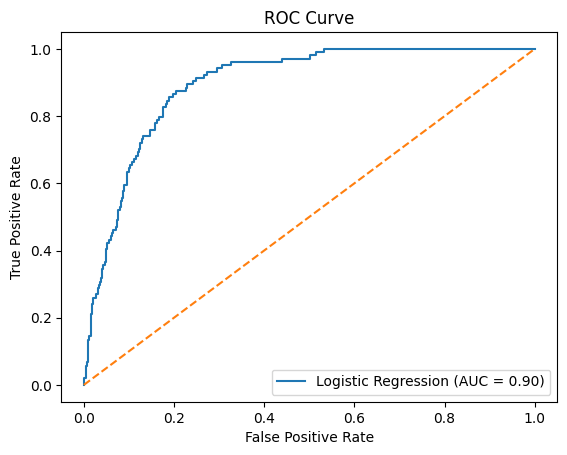

In [ ]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label="Logistic Regression (AUC = %0.2f)" % roc_auc)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

# TPR - True Poritive Rate or Recall
# FPR - False Positive Rate


Inference

The confusion matrix shows how the model distinguishes between risky and non-risky customers.
A low False Negative rate is important, since missing risky customers could lead to financial losses for the bank.



Precision - High precision means that when the model flags a customer as risky, it is usually correct. This reduces unnecessary investigation of low-risk customers.



Rrecall ( PTR ) - Out of all actual risky customers, how many the model detected.



F1 Score - Balanced measure of precision and recall.

Implementing all the 3 LR Types

1. L1 Regularized Logistic Regression (Lasso)

2. L2 Regularized Logistic Regression (Ridge)

3. Elastic Net Logistic Regression (L1 + L2)

In [ ]:
def evaluate_model(model, x_test, y_test):
    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)[:,1]

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

    return y_prob

In [ ]:
# L2 - Ridge - Default in LR

lr_ridge = LogisticRegression(
    penalty='l2',
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced'
)

lr_ridge.fit(x_train, y_train)

print("===== L2 - Ridge Logistic Regression =====")
y_prob_l2 = evaluate_model(lr_ridge, x_test, y_test)

===== L2 - Ridge Logistic Regression =====
Accuracy: 0.8165745856353591

Confusion Matrix:
 [[651 150]
 [ 16  88]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.81      0.89       801
           1       0.37      0.85      0.51       104

    accuracy                           0.82       905
   macro avg       0.67      0.83      0.70       905
weighted avg       0.91      0.82      0.84       905

ROC-AUC Score: 0.8953351579756075


In [ ]:
# L1 - Lasso - Strict algorithm

lr_lasso = LogisticRegression(
    penalty='l1',
    solver='liblinear',   # supports L1
    max_iter=1000,
    class_weight='balanced'
)

lr_lasso.fit(x_train, y_train)

print("===== L1 - Lasso Logistic Regression =====")
y_prob_l1 = evaluate_model(lr_lasso, x_test, y_test)

===== L1 - Lasso Logistic Regression =====
Accuracy: 0.8165745856353591

Confusion Matrix:
 [[651 150]
 [ 16  88]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.81      0.89       801
           1       0.37      0.85      0.51       104

    accuracy                           0.82       905
   macro avg       0.67      0.83      0.70       905
weighted avg       0.91      0.82      0.84       905

ROC-AUC Score: 0.8949630269854989


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV

# Base LR model
lr_en = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    l1_ratio=0.3,          # slightly smoother than 0.5
    max_iter=2000,
    class_weight='balanced',
    C=0.5                  # stronger regularization
)

# Calibrate probabilities
calibrated_lr = CalibratedClassifierCV(
    estimator=lr_en,
    method='sigmoid',
    cv=5
)

calibrated_lr.fit(x_train, y_train)

print("===== Calibrated Elastic Net Logistic Regression =====")
y_prob_en = evaluate_model(calibrated_lr, x_test, y_test)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


===== Calibrated Elastic Net Logistic Regression =====
Accuracy: 0.8961325966850828

Confusion Matrix:
 [[784  17]
 [ 77  27]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.98      0.94       801
           1       0.61      0.26      0.36       104

    accuracy                           0.90       905
   macro avg       0.76      0.62      0.65       905
weighted avg       0.88      0.90      0.88       905

ROC-AUC Score: 0.8954311917795064


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [ ]:
from sklearn.metrics import f1_score, roc_auc_score

results = {
    "L2 - Ridge": {
        "y_pred": lr_ridge.predict(x_test),
        "y_prob": y_prob_l2
    },
    "L1 - Lasso": {
        "y_pred": lr_lasso.predict(x_test),
        "y_prob": y_prob_l1
    },
    "Elastic Net": {
        "y_pred": calibrated_lr.predict(x_test),
        "y_prob": y_prob_en
    }
}

In [ ]:
import pandas as pd

metrics_list = []

for name, res in results.items():
    f1 = f1_score(y_test, res["y_pred"])
    roc = roc_auc_score(y_test, res["y_prob"])

    metrics_list.append({
        "Model": name,
        "F1 Score": f1,
        "ROC-AUC": roc
    })

metrics_df = pd.DataFrame(metrics_list)
print(metrics_df)

         Model  F1 Score   ROC-AUC
0   L2 - Ridge  0.514620  0.895335
1   L1 - Lasso  0.514620  0.894963
2  Elastic Net  0.364865  0.895431


In [ ]:
best_roc_model = metrics_df.loc[metrics_df["ROC-AUC"].idxmax()]
print("\nBest Model by ROC-AUC:")
print(best_roc_model)


Best Model by ROC-AUC:
Model       Elastic Net
F1 Score       0.364865
ROC-AUC        0.895431
Name: 2, dtype: object


In [ ]:
best_f1_model = metrics_df.loc[metrics_df["F1 Score"].idxmax()]
print("\nBest Model by F1 Score:")
print(best_f1_model)


Best Model by F1 Score:
Model       L2 - Ridge
F1 Score       0.51462
ROC-AUC       0.895335
Name: 0, dtype: object


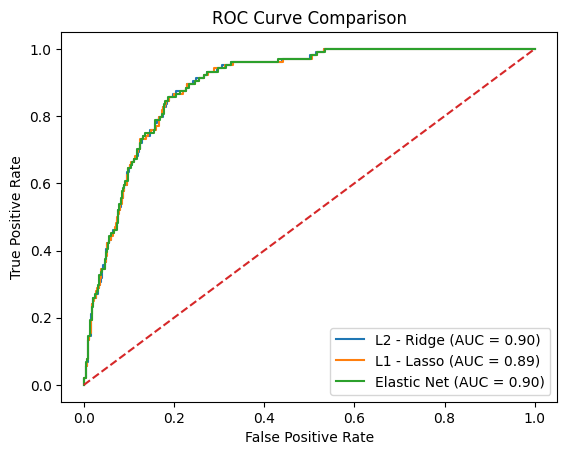

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

plt.figure()

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    auc = roc_auc_score(y_test, res["y_prob"])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.show()